# Homework 3: Open-Ended Data Project (APIs, Merging, & Analysis)

- **Course**: Data Science for Public Policy  
- **Assignment Type**: Open-Ended Policy Research Project  

### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Crucial Project Requirements**

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.
  - Alternatively, you may upload a local file, provided it is committed to your repository.
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
- **Mandatory Local Path & Directory Structure**
  - All homework-specific datasets must be stored in the dedicated local directory: `data/hw/hw_3/`.
  - If the directory `data/hw/hw_3/` does not exist in your workspace, you must create it.
  - Any primary or secondary dataset that you download, write, or load locally must live inside `data/hw/hw_3/`.
- **Working Directory & Relative Paths**
  - Since this Jupyter notebook resides in `notebooks/hw/hw_3/`, its default working directory is set to that folder.
  - To load files using clean relative paths from the project root (like `data/hw/hw_3/my_data.csv` or `data/examples/week_5/world_happiness.parquet`), you must programmatically change your working directory to the project root at the start of your notebook.
  - In Part 1, we show you how to use `os.getcwd()` and `os.chdir()` to change your working directory. Once changed, all relative paths starting with `data/` will resolve perfectly.
  - Never hardcode absolute paths specific to your local machine (like `/Users/username/...`).
- **Reproducibility**
  - Commit both this notebook and the datasets in `data/hw/hw_3/` so that your grader can run all cells from top to bottom out-of-the-box.

---

### **Example Datasets for Selection**

To help you select an interesting topic, we have highlighted a few high-quality, policy-relevant datasets below. You are highly encouraged to explore these or check the complete menu of over 100 macroeconomic and public policy datasets available in the [Dataset Reference Guide](file:///Users/cory/Desktop/datascience-publicpolicy-2026/docs/example_datasets.md).

Here are some curated examples to consider:

1. **World Development Indicators (WDI) - World Bank**
   * **Policy Relevance**: Explore global development indicators such as GDP growth, life expectancy, inflation, and trade volumes across 200+ countries.
   * **Variables**: GDP per capita, life expectancy, inflation rate, export volumes, and foreign direct investment.

2. **World Happiness Report**
   * **Policy Relevance**: Investigate the economic and social factors that influence subjective well-being across 140+ countries.
   * **Variables**: Life satisfaction (ladder score), social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption.

3. **Oxford COVID-19 Government Response Tracker (OxCGRT)**
   * **Policy Relevance**: Evaluate how government policy measures relate to public health indicators or economic outcomes across 180+ countries.
   * **Variables**: School closing, workplace closing, travel restrictions, vaccine policies, and the Stringency Index.

4. **Standardized World Income Inequality Database (SWIID)**
   * **Policy Relevance**: Compare income inequality trends and redistributive policy outcomes across countries and time.
   * **Variables**: Gini coefficient for market income, Gini coefficient for disposable income, and redistributive transfers.

5. **IMF World Economic Outlook (WEO)**
   * **Policy Relevance**: Examine macroeconomic trends, fiscal positions, and short-to-medium-term economic forecasts across 196 countries.
   * **Variables**: Real GDP growth, consumer price inflation, general government gross debt, current account balance, and unemployment rate.

For the full reference guide containing detailed information on over 100 datasets, including themes, variables, and links, please refer to:
* **Dataset Reference Guide**: [docs/example_datasets.md](file:///Users/cory/Desktop/datascience-publicpolicy-2026/docs/example_datasets.md)

---

### **Grading Criteria**

- **Data Acquisition & Environment Preparation**
  - Programmatic download or loading via committed relative paths.
  - Verification of directory structure using environment tools.
- **Cleaning & Preprocessing**
  - Standardizing names, selecting relevant subsets, and handling missing values.
- **Merging Datasets**
  - Programmatic merge on a matching key (like country code or year).
- **Aggregation & Groupby Analysis**
  - Category segmentation or custom binning for datasets without natural categories.
- **Visualization & Exploratory Modeling**
  - Beautiful, fully customized plots.
  - Regression model with slope and policy interpretation.

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup & Working Directory Alignment**
  - By default, your working directory is the folder where this notebook is located (`notebooks/hw/hw_3`).
  - To use standard project-root relative paths, you must programmatically change your working directory to the project root.
  - Use Python's `os` library (reviewed in Week 3) to check if your working directory is `notebooks/hw/hw_3` or the root. If it is `notebooks/hw/hw_3`, use `os.chdir()` to navigate up to the project root.
  - Print the aligned working directory using `os.getcwd()` and list the files in the directory using `os.listdir()` to verify that the `data/hw/hw_3/` folder is visible.
- **Local Path Validation**
  - Check if the dedicated folder `data/hw/hw_3/` exists. If it does not exist, use `os.makedirs()` to create the directory `data/hw/hw_3/` programmatically.
- **Acquisition & Storage Steps**
  - Programmatically fetch your primary dataset using `requests` or read it from a public URL.
  - Save the downloaded dataset directly into the local path: `data/hw/hw_3/` (for example, `data/hw/hw_3/primary_dataset.csv`).
  - Load the primary dataset into a Pandas DataFrame using its local path `data/hw/hw_3/primary_dataset.csv` (or the appropriate file extension) to ensure all subsequent analysis is fully local and reproducible.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [5]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

# 1. Print environment details and change the working directory to the project root.
# If the current folder is 'notebooks/hw/hw_3', change to the project root so that 'data/hw/hw_3/' is accessible via relative paths.
# Print os.getcwd() before and after the change to confirm alignment.
# Verify that the local path 'data/hw/hw_3/' exists, or create it programmatically using os.makedirs() if it does not.

print("Current working directory before change:", os.getcwd())
if os.path.normpath(os.getcwd()).endswith(os.path.join('notebooks', 'hw', 'hw_3')):
    os.chdir('../../../')
print("CWD After Change:", os.getcwd())
target_folder = 'data/hw/hw_3/'
if not os.path.exists(target_folder):
    os.makedirs(target_folder)


# 2. Acquire and load your primary dataset.
# Programmatically download your data (or load a committed local file) and save it directly inside 'data/hw/hw_3/'.
# Read the dataset from its local path 'data/hw/hw_3/your_file.csv' (or parquet/json) into a Pandas DataFrame.

data_path = "data/hw/hw_3/emdat_data.xlsx"
df_clean = pd.read_excel(data_path, engine="openpyxl")
print ("Success! EM-DAT loaded properly. Here are the columns:")
print(list(df_clean.columns))




Current working directory before change: c:\Users\Mariam\Desktop\DataScience\datascience-publicpolicy-2026-main\datascience-publicpolicy-2026\notebooks\hw\hw_3
CWD After Change: c:\Users\Mariam\Desktop\DataScience\datascience-publicpolicy-2026-main\datascience-publicpolicy-2026
Success! EM-DAT loaded properly. Here are the columns:
['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).
- **Policy Relevance**
  - Detail why this dataset is important for public policy decisions.
  - List the primary variables of interest for your research.

- *Write your source and relevance bullets here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [6]:
# 1. Inspect data structure using pandas methods

df = df_clean.copy()
df.info()
df.head(25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405 entries, 0 to 1404
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     1405 non-null   object 
 1   Historic                                   1405 non-null   object 
 2   Classification Key                         1405 non-null   object 
 3   Disaster Group                             1405 non-null   object 
 4   Disaster Subgroup                          1405 non-null   object 
 5   Disaster Type                              1405 non-null   object 
 6   Disaster Subtype                           1405 non-null   object 
 7   External IDs                               759 non-null    object 
 8   Event Name                                 240 non-null    object 
 9   ISO                                        1405 non-null   object 
 10  Country                 

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2006-0454-HUN,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),HANZE:20516,NaN,HUN,...,NaN,5000.0,7985.0,10000.0,15970.0,62.617195,"[{""adm1_code"":1444,""adm1_name"":""Budapest""}]",NaN,2007-03-15,2025-11-17
1,2026-0047-GBR,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Ingrid' & 'Chandra',GBR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-29,2026-02-16
2,2026-0014-BIH,No,nat-met-sto-sev,Natural,Meteorological,Storm,Severe weather,NaN,NaN,BIH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-08,2026-02-16
3,2026-0098-ESP,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Nils',ESP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-13,2026-02-16
4,2026-0098-PRT,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Nils',PRT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-19,2026-02-25
5,2026-0098-FRA,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Nils',FRA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-12,2026-02-25
6,2026-0206-HRV,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Deborah',HRV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-31,2026-04-03
7,2026-0009-FRA,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,FRA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07,2026-04-17
8,2026-0009-BIH,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,BIH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07,2026-04-17
9,2026-0009-NLD,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,NLD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07,2026-04-17


In [11]:
# 2. Rename columns and select a clean subset

df_renamed = df_clean.rename(columns={
    "Year": "year",
    "Country": "country",
    "ISO": "country_code",
    "Disaster Group": "disaster_group",
    "Disaster Type": "disaster_type",
    "Total Deaths": "deaths",
    "Total Affected": "total_affected",
    "Total Damages (USD)": "damage_usd_thousands"
})

In [14]:
# 3. Handle missing values (NaNs)

columns_to_keep = ['country', 'country_code', 'disaster_group', 'disaster_type', 'year', 'deaths', 'total_affected', 'damage_usd_thousands']
df_renamed = df_renamed.rename(columns={
    "Start Year": "year",
    "Total Damage ('000 US$)": "damage_usd_thousands"
})
df_subset = df_renamed[columns_to_keep]
df_subset = df_subset.dropna(subset=['country', 'year', 'disaster_type'])
df_subset['deaths'] = df_subset['deaths'].fillna(5)
df_subset['total_affected'] = df_subset['total_affected'].fillna(5)
df_subset['damage_usd_thousands'] = df_subset['damage_usd_thousands'].fillna(5)
print("Data after cleaning:")
print(df_subset.info())
print(df_subset.head(25))
print("Final Dataset Shape:", df_subset.shape)
df_subset.head(40)


Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405 entries, 0 to 1404
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               1405 non-null   object 
 1   country_code          1405 non-null   object 
 2   disaster_group        1405 non-null   object 
 3   disaster_type         1405 non-null   object 
 4   year                  1405 non-null   int64  
 5   deaths                1405 non-null   float64
 6   total_affected        1405 non-null   float64
 7   damage_usd_thousands  1405 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 87.9+ KB
None
                                              country country_code  \
0                                             Hungary          HUN   
1   United Kingdom of Great Britain and Northern I...          GBR   
2                              Bosnia and Herzegovina          BIH   
3              

,country,country_code,disaster_group,disaster_type,year,deaths,total_affected,damage_usd_thousands
0,Hungary,HUN,Natural,Storm,2006,5.0,300.0,10000.0
1,United Kingdom of Great Britain and Northern I...,GBR,Natural,Storm,2026,1.0,180.0,5.0
2,Bosnia and Herzegovina,BIH,Natural,Storm,2026,1.0,5.0,5.0
3,Spain,ESP,Natural,Storm,2026,2.0,90.0,5.0
4,Portugal,PRT,Natural,Storm,2026,2.0,5.0,5.0
5,France,FRA,Natural,Storm,2026,4.0,26.0,5.0
6,Croatia,HRV,Natural,Storm,2026,5.0,152.0,5.0
7,France,FRA,Natural,Storm,2026,6.0,305.0,5.0
8,Bosnia and Herzegovina,BIH,Natural,Storm,2026,1.0,5.0,5.0
9,Netherlands (Kingdom of the),NLD,Natural,Storm,2026,5.0,5.0,5.0


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Load a secondary dataset relative to the project root.
  - You can load one of the provided datasets in the Week 5 examples directory, such as `data/examples/week_5/world_happiness.parquet` or `data/examples/week_5/imf_weo_countries.parquet`.
  - Alternatively, you can programmatically download another related dataset. If you download a custom secondary dataset, save it inside your local path `data/hw/hw_3/` alongside your primary dataset.
- **Path Verification**
  - Ensure the file path used to load the secondary dataset (e.g., `data/examples/week_5/world_happiness.parquet` or `data/hw/hw_3/secondary_dataset.csv`) is relative to the project root working directory set in Part 1.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [15]:
# 1. Load and clean the secondary dataset.
# Load a dataset from 'data/examples/week_5/' (e.g., 'data/examples/week_5/world_happiness.parquet')
# or load a custom dataset saved in your local path 'data/hw/hw_3/'.

import pandas as pd
df_clean = pd.read_excel ("data/hw/hw_3/emdat_tech_asia.xlsx")
df_renamed = df_clean.rename(columns={
    'Country': 'country',
    'ISO': 'country_code',
    'Region': 'region',
    'Start Year': 'year',
    'Disaster Group': 'disaster_group',
    'Disaster Type': 'disaster_type',
    'Total Deaths': 'deaths',
    'Total Affected': 'total_affected',
    "Total Damage ('000 US$)": 'damage_usd_thousands'
})
columns_to_keep = ['country', 'country_code', 'region', 'year', 'disaster_type', 'deaths', 'total_affected', 'damage_usd_thousands']
df_subset = df_renamed[columns_to_keep].copy()
is_asia = df_subset['region'].str.contains('Asia', na=False)
df_filtered = df_subset[is_asia].copy()
df_final = df_filtered.dropna(subset=['country', 'year'])
df_final['deaths'] = df_final['deaths'].fillna(5)
df_final['total_affected'] = df_final['total_affected'].fillna(5)
df_final['damage_usd_thousands'] = df_final['damage_usd_thousands'].fillna(5)
print("Final Clean Dataset Shape:", df_final.shape)
df_final.head(20)


Final Clean Dataset Shape: (2583, 8)


,country,country_code,region,year,disaster_type,deaths,total_affected,damage_usd_thousands
0,Malaysia,MYS,Asia,2026,Fire (Miscellaneous),5.0,9007.0,5.0
1,China,CHN,Asia,2000,Road,25.0,11.0,5.0
2,India,IND,Asia,2006,Road,27.0,5.0,5.0
3,India,IND,Asia,2007,Road,80.0,130.0,5.0
4,Türkiye,TUR,Asia,2007,Water,49.0,5.0,5.0
5,Taiwan (Province of China),TWN,Asia,2000,Air,82.0,79.0,5.0
6,China,CHN,Asia,2003,Road,27.0,6.0,5.0
7,Bangladesh,BGD,Asia,2005,Water,75.0,5.0,5.0
8,India,IND,Asia,2005,Water,50.0,5.0,5.0
9,Nepal,NPL,Asia,2005,Water,28.0,5.0,5.0


In [16]:
# 2. Merge your datasets on a common key

import pandas as pd
df_natural = pd.read_excel(data_path, engine="openpyxl")
tech_path = "data/hw/hw_3/emdat_tech_asia.xlsx"
df_tech = pd.read_excel(tech_path, engine="openpyxl")
df_combined = pd.concat([df_natural, df_tech], ignore_index=True)
df_renamed = df_combined.rename(columns={
    'Country': 'country',
    'ISO': 'country_code',
    'Region': 'region',
    'Start Year': 'year',
    'Disaster Group': 'disaster_group',
    'Disaster Type': 'disaster_type',
    'Total Deaths': 'deaths',
    'Total Affected': 'total_affected',
    "Total Damage ('000 US$)": 'damage_usd_thousands'
})
columns_to_keep = ['country', 'country_code', 'region', 'year', 'disaster_type', 'deaths', 'total_affected', 'damage_usd_thousands']
df_final = df_renamed[columns_to_keep].copy()
df_final = df_final.dropna(subset=['country', 'year'])
df_final['deaths'] = df_final['deaths'].fillna(5)
df_final['total_affected'] = df_final['total_affected'].fillna(5)
df_final['damage_usd_thousands'] = df_final['damage_usd_thousands'].fillna(5)
df_final['disaster_type'] = df_final['disaster_type'].fillna('Unknown')
print("=== COMBINED EM-DAT DATASET ===")
print(f"Total rows in combined dataset: {df_final.shape[0]}")
print("\nBreakdown of disasters in your data:")
columns_to_keep = [
    'country',
    'country_code',
    'region',
    'year',
    'disaster_group',
    'disaster_type',
    'deaths',
    'total_affected',
    'damage_usd_thousands'
]
df_final = df_renamed[columns_to_keep].copy()
df_final = df_final.dropna(subset=['country', 'year'])
df_final['deaths'] = df_final['deaths'].fillna(5)
df_final['total_affected'] = df_final['total_affected'].fillna(5)
df_final['damage_usd_thousands'] = df_final['damage_usd_thousands'].fillna(5)
df_final['disaster_type'] = df_final['disaster_type'].fillna('Unknown')
print("=== COMBINED EM-DAT DATASET ===")
print(f"Total rows in combined dataset: {df_final.shape[0]}")
print("\nBreakdown of disasters in your data:")
print(df_final['disaster_group'].value_counts())
print("="*40)
df_final.head(35)


=== COMBINED EM-DAT DATASET ===
Total rows in combined dataset: 3988

Breakdown of disasters in your data:
=== COMBINED EM-DAT DATASET ===
Total rows in combined dataset: 3988

Breakdown of disasters in your data:
disaster_group
Technological    2583
Natural          1405
Name: count, dtype: int64


,country,country_code,region,year,disaster_group,disaster_type,deaths,total_affected,damage_usd_thousands
0,Hungary,HUN,Europe,2006,Natural,Storm,5.0,300.0,10000.0
1,United Kingdom of Great Britain and Northern I...,GBR,Europe,2026,Natural,Storm,1.0,180.0,5.0
2,Bosnia and Herzegovina,BIH,Europe,2026,Natural,Storm,1.0,5.0,5.0
3,Spain,ESP,Europe,2026,Natural,Storm,2.0,90.0,5.0
4,Portugal,PRT,Europe,2026,Natural,Storm,2.0,5.0,5.0
5,France,FRA,Europe,2026,Natural,Storm,4.0,26.0,5.0
6,Croatia,HRV,Europe,2026,Natural,Storm,5.0,152.0,5.0
7,France,FRA,Europe,2026,Natural,Storm,6.0,305.0,5.0
8,Bosnia and Herzegovina,BIH,Europe,2026,Natural,Storm,1.0,5.0,5.0
9,Netherlands (Kingdom of the),NLD,Europe,2026,Natural,Storm,5.0,5.0,5.0


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [17]:
# Apply groupby aggregation or implement one of the backup grouping strategies

group_summary = df_final.groupby('disaster_group').agg({
    'deaths': 'sum',
    'total_affected': 'sum',
    'damage_usd_thousands': 'sum'
})

print("=== IMPACT ANALYSIS BY DISASTER GROUP ===")
print(group_summary)
print("\n" + "="*50 + "\n")
country_summary = df_final.groupby('country').agg({
    'deaths': 'sum',
    'total_affected': 'sum'
})
top_countries = country_summary.sort_values(by='deaths', ascending=False).head(10)

print("=== TOP 10 MOST IMPACTED COUNTRIES (BY DEATH TOLL) ===")
print(top_countries)

=== IMPACT ANALYSIS BY DISASTER GROUP ===
                  deaths  total_affected  damage_usd_thousands
disaster_group                                                
Natural         332524.0      20327602.0           328678307.0
Technological    84960.0       1470886.0            16088211.0


=== TOP 10 MOST IMPACTED COUNTRIES (BY DEATH TOLL) ===
                                                     deaths  total_affected
country                                                                    
Italy                                               71078.0        361782.0
Russian Federation                                  58638.0       4175231.0
Spain                                               42104.0        146811.0
France                                              38104.0       1212606.0
Germany                                             30686.0        346549.0
China                                               19017.0        286037.0
Greece                                   

### **Policy Insights**

- **Observed Patterns**
  - Describe the differences in indicators between the subgroups.
- **Policy Implications**
  - Interpret the results for a public policy audience.

- *Write your policy insight bullets here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

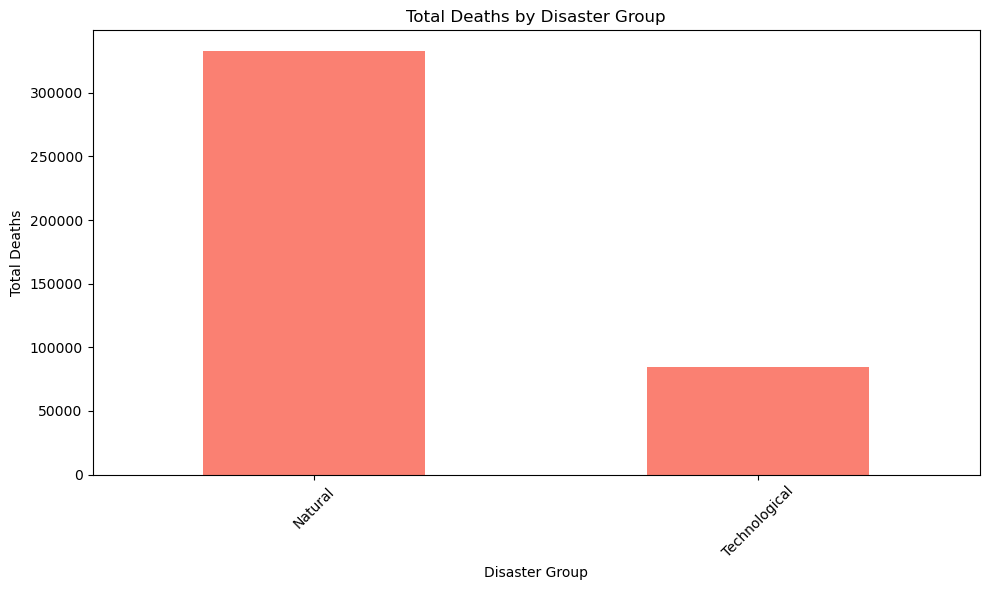

In [19]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_final.groupby('disaster_group')['deaths'].sum().sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Total Deaths by Disaster Group')
plt.xlabel('Disaster Group')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


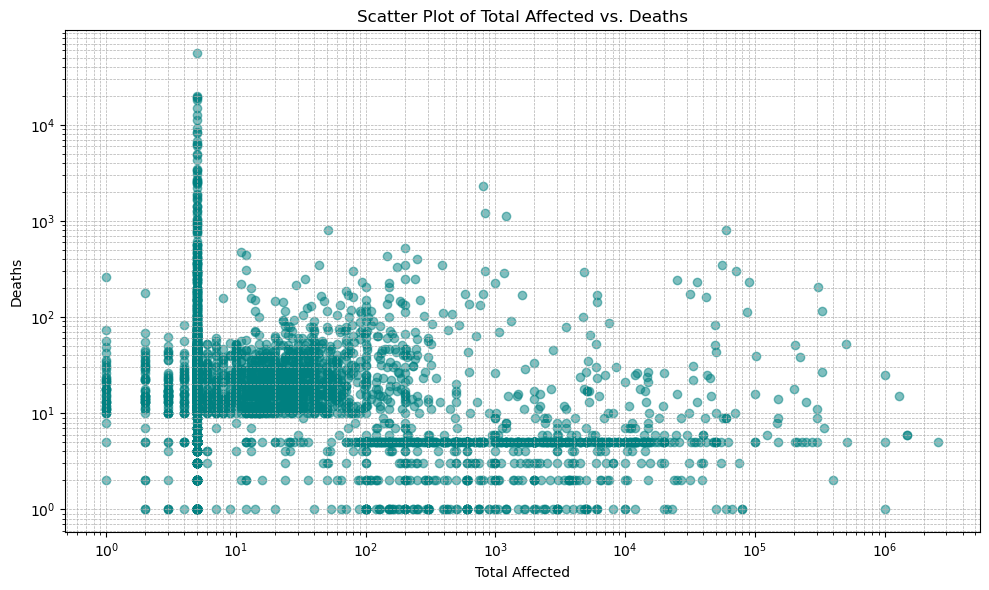

In [20]:
# Plot 2: Customized scatter plot of primary policy variables

plt.figure(figsize=(10, 6))
plt.scatter(df_final['total_affected'], df_final['deaths'], alpha=0.5, color='teal')
plt.title('Scatter Plot of Total Affected vs. Deaths')
plt.xlabel('Total Affected')
plt.ylabel('Deaths')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                 deaths   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     8.672
Date:                Wed, 17 Jun 2026   Prob (F-statistic):            0.00328
Time:                        11:39:59   Log-Likelihood:                -9029.8
No. Observations:                1539   AIC:                         1.806e+04
Df Residuals:                    1537   BIC:                         1.807e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             34.9714      2.185     16.

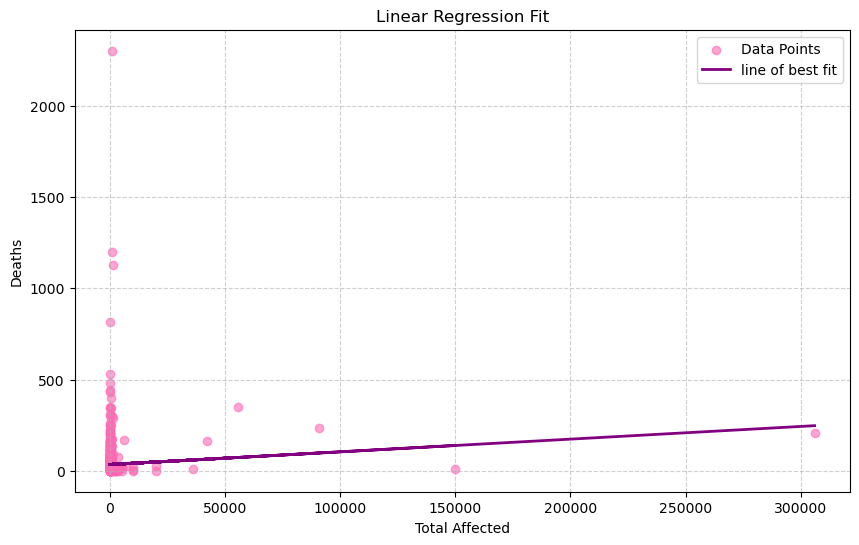

In [29]:
# Fit a simple linear regression and overlay the line of best fit

import statsmodels.api as sm
import matplotlib.pyplot as plt
X = df_subset['total_affected'] 
Y = df_subset['deaths']
X_with_constant = sm.add_constant(X)
model = sm.OLS(Y, X_with_constant, missing='drop').fit()
print(model.summary())
plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='hotpink', alpha=0.6, label='Data Points')
plt.plot(X, model.predict(X_with_constant), color='purple', linewidth=2, label='line of best fit')
plt.title('Linear Regression Fit')
plt.xlabel('Total Affected')
plt.ylabel('Deaths')
plt.legend()
plt.grid (True, linestyle='--', alpha=0.6)
plt.show()

### **Interpretation of Results**

- **Visual Findings**
  - Summarize what the charts reveal about the policy issue.
- **Model Interpretation**
  - Interpret the slope coefficient from the regression.
  - Explain what the coefficient implies in real-world public policy terms.

- *Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the datasets are saved and committed in Git.
  - Ensure all files are loaded using relative paths from the project root.
  - Double-check that your primary dataset (and custom secondary dataset, if any) is saved in the local path `data/hw/hw_3/`.
  - Confirm that no absolute local paths (e.g., `/Users/username/...`) are used in any loading or saving step.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.
- **Clean Code Hygiene**
  - Ensure intermediate debug prints are removed and the notebook is polished.